# SQUIGGLES

In [ ]:
# %%
import numpy as np
from scipy.interpolate import make_interp_spline
from PIL import Image, ImageDraw
import random
import argparse
import json



def generate_spline_squiggle(num_anchors=50, width=200, height=200):
    center = np.array([width // 2, height // 2])
    boundary = 100  # Max distance from center
    min_dist = 30   # Goldilocks: Not too close (to previous point)
    max_dist = 100  # Goldilocks: Not too far (from previous point)
    min_dist_all = 15  # Minimum distance to ANY existing point (prevents clustering)

    # 1. Generate "Goldilocks" Anchor Points with uniform spacing
    anchors = [center.astype(float)]
    
    for _ in range(num_anchors):
        found = False
        attempts = 0
        while not found and attempts < 100:
            # Pick a random direction and distance
            angle = random.uniform(0, 2 * np.pi)
            dist = random.uniform(min_dist, max_dist)
            
            new_point = anchors[-1] + np.array([np.cos(angle) * dist, np.sin(angle) * dist])
            
            # Check global boundary constraint
            if np.linalg.norm(new_point - center) < boundary:
                # Check distance to ALL existing points to avoid high-density areas
                distances_to_all = [np.linalg.norm(new_point - existing) for existing in anchors]
                if all(d >= min_dist_all for d in distances_to_all):
                    anchors.append(new_point)
                    found = True
            attempts += 1

    anchors = np.array(anchors)

    # print(len(anchors))

    # 2. Create the Spline
    # 'k=3' creates a cubic spline (smooth curves)
    # We create a parameter 't' based on the number of points
    t = np.linspace(0, 1, len(anchors))
    t_smooth = np.linspace(0, 1, len(anchors) * 100)  # More points for smoother curves
    
    spline_func = make_interp_spline(t, anchors, k=3)
    smooth_points = spline_func(t_smooth)

    # 3. Draw the result with anti-aliasing (supersampling)
    # Draw at 4x resolution, then downsample for smooth edges
    scale = 4
    img_large = Image.new("RGB", (width * scale, height * scale), "white")
    draw = ImageDraw.Draw(img_large)
    
    # Scale up the points
    path = [tuple(p * scale) for p in smooth_points]
    
    draw.line(path, fill=(20, 20, 20), width=4 * scale, joint="curve")
    
    # Downsample for anti-aliasing
    img = img_large.resize((width, height), Image.LANCZOS)

    # img.save("spline_squiggle.png")
    return img


In [ ]:
import os

num_anchors_list = [20, 30, 40, 50,100]
num_images = 10

for num_anchors in num_anchors_list:
    folder = f"squiggles_{num_anchors}_v2"
    os.makedirs(folder, exist_ok=True)

    for i in range(num_images):
        img = generate_spline_squiggle(num_anchors=num_anchors)
        img.save(f"{folder}/squiggle_{i}.png")

31
31
31
31
31
31
31
31
31
31


# PERLIN CONTOUR

In [14]:
import numpy as np
from PIL import Image, ImageDraw
from noise import pnoise2
import argparse
import json


def generate_perlin_contour(
    octaves=4,
    width=100,
    height=100,
    iso=0.05,
    scale=0.08,        # noise coordinate zoom — smaller = more zoomed in (larger features)
    offset_x=0.0,      # translate in noise space (change for different samples)
    offset_y=0.0,
):
    """
    Generate a contour line image by running marching squares over a 2D
    fractional Brownian motion (fBm) Perlin noise field.

    Parameters
    ----------
    octaves   : int   — fBm octaves; more = finer detail on top of same base shape
    width/height : int — output image size in pixels
    iso       : float — isosurface threshold; shifts which contours appear
    scale     : float — noise coordinate step; controls spatial frequency of features
    offset_x/y: float — offset into noise space; use to get different samples at same octaves
    """

    res = 200  # marching squares grid resolution (independent of image size)

    # 1. Sample the fBm noise field
    field = np.zeros((res + 1, res + 1))
    for j in range(res + 1):
        for i in range(res + 1):
            field[j, i] = pnoise2(
                i * scale + offset_x,
                j * scale + offset_y,
                octaves=octaves,
                persistence=0.5,
                lacunarity=2.0,
            )

    # 2. Marching squares — collect line segments at iso level
    segments = []
    for j in range(res):
        for i in range(res):
            v = [field[j, i], field[j, i+1], field[j+1, i+1], field[j+1, i]]
            c = [1 if x > iso else 0 for x in v]
            idx = c[0]*8 + c[1]*4 + c[2]*2 + c[3]
            if idx == 0 or idx == 15:
                continue

            def lerp_edge(a, b):
                if abs(b - a) < 1e-10:
                    return 0.5
                return (iso - a) / (b - a)

            # Edge intersection points in grid coordinates
            top    = (i + lerp_edge(v[0], v[1]), j)
            right  = (i + 1,                     j + lerp_edge(v[1], v[2]))
            bottom = (i + lerp_edge(v[3], v[2]), j + 1)
            left   = (i,                          j + lerp_edge(v[0], v[3]))

            active = []
            if c[0] != c[1]: active.append(top)
            if c[1] != c[2]: active.append(right)
            if c[2] != c[3]: active.append(bottom)
            if c[3] != c[0]: active.append(left)

            if len(active) == 2:
                segments.append((active[0], active[1]))

    # 3. Draw with supersampling for anti-aliasing
    sup = 4
    img_large = Image.new("RGB", (width * sup, height * sup), "white")
    draw = ImageDraw.Draw(img_large)

    def grid_to_px(gx, gy):
        # map grid coords [0, res] -> image pixels [0, width*sup]
        return (gx / res * width * sup, gy / res * height * sup)

    for (ax, ay), (bx, by) in segments:
        p1 = grid_to_px(ax, ay)
        p2 = grid_to_px(bx, by)
        draw.line([p1, p2], fill=(20, 20, 20), width=4 * sup)

    img = img_large.resize((width, height), Image.LANCZOS)
    return img



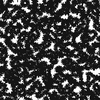

In [15]:
img = generate_perlin_contour(
        octaves=5,
        # width=args.width,
        # height=args.height,
        # iso=args.iso,
        # scale=args.scale,
        # offset_x=args.offset_x,
        # offset_y=args.offset_y,
    )

img

# MAZES

In [34]:
import numpy as np
from PIL import Image, ImageDraw
import random


def generate_maze(
    grid_size=15,
    width=200,
    height=200,
    algorithm="dfs",   # "dfs" | "prim" | "wilson"
    seed=None,
):
    """
    Generate a maze image using a perfect-maze algorithm.

    Parameters
    ----------
    grid_size : int   — number of cells per side; larger = more complex / denser walls
    width/height : int — output image size in pixels
    algorithm : str   — maze generation algorithm
    seed : int | None — random seed for reproducibility
    """
    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)

    cols, rows = grid_size, grid_size

    # Adjacency: for each cell store which neighbours the passage is open to
    # Directions: 0=N, 1=E, 2=S, 3=W
    DX = [0, 1, 0, -1]
    DY = [-1, 0, 1, 0]
    OPPOSITE = [2, 3, 0, 1]

    passages = [[set() for _ in range(cols)] for _ in range(rows)]  # passages[y][x]

    def in_bounds(x, y):
        return 0 <= x < cols and 0 <= y < rows

    def carve(x, y, d):
        nx, ny = x + DX[d], y + DY[d]
        passages[y][x].add(d)
        passages[ny][nx].add(OPPOSITE[d])

    # ------------------------------------------------------------------ DFS --
    def build_dfs():
        visited = [[False]*cols for _ in range(rows)]
        stack = [(0, 0)]
        visited[0][0] = True
        while stack:
            x, y = stack[-1]
            dirs = list(range(4))
            rng.shuffle(dirs)
            moved = False
            for d in dirs:
                nx, ny = x + DX[d], y + DY[d]
                if in_bounds(nx, ny) and not visited[ny][nx]:
                    carve(x, y, d)
                    visited[ny][nx] = True
                    stack.append((nx, ny))
                    moved = True
                    break
            if not moved:
                stack.pop()

    # ----------------------------------------------------------------- Prim --
    def build_prim():
        visited = [[False]*cols for _ in range(rows)]
        sx, sy = 0, 0
        visited[sy][sx] = True
        frontier = []
        for d in range(4):
            nx, ny = sx + DX[d], sy + DY[d]
            if in_bounds(nx, ny):
                frontier.append((sx, sy, d))

        while frontier:
            idx = rng.randrange(len(frontier))
            x, y, d = frontier[idx]
            frontier[idx] = frontier[-1]
            frontier.pop()
            nx, ny = x + DX[d], y + DY[d]
            if not in_bounds(nx, ny) or visited[ny][nx]:
                continue
            carve(x, y, d)
            visited[ny][nx] = True
            for nd in range(4):
                nnx, nny = nx + DX[nd], ny + DY[nd]
                if in_bounds(nnx, nny) and not visited[nny][nnx]:
                    frontier.append((nx, ny, nd))

    # --------------------------------------------------------------- Wilson --
    def build_wilson():
        in_maze = [[False]*cols for _ in range(rows)]
        in_maze[0][0] = True
        remaining = [(x, y) for y in range(rows) for x in range(cols) if not (x == 0 and y == 0)]
        rng.shuffle(remaining)

        while remaining:
            # random walk from an unvisited cell until hitting the maze
            sx, sy = remaining[0]
            path = [(sx, sy)]
            path_set = {(sx, sy): 0}
            while not in_maze[path[-1][1]][path[-1][0]]:
                x, y = path[-1]
                d = rng.randrange(4)
                nx, ny = x + DX[d], y + DY[d]
                if not in_bounds(nx, ny):
                    continue
                if (nx, ny) in path_set:
                    # loop-erase
                    loop_start = path_set[(nx, ny)]
                    for cell in path[loop_start+1:]:
                        del path_set[cell]
                    path = path[:loop_start+1]
                else:
                    path.append((nx, ny))
                    path_set[(nx, ny)] = len(path) - 1

            # carve the path into the maze
            for i in range(len(path) - 1):
                x, y = path[i]
                nx, ny = path[i+1]
                d = [k for k in range(4) if (x+DX[k], y+DY[k]) == (nx, ny)][0]
                carve(x, y, d)
                in_maze[y][x] = True
                if (x, y) in path_set:
                    remaining.remove((x, y)) if (x, y) in remaining else None

            remaining = [(x, y) for x, y in remaining if not in_maze[y][x]]

    builders = {"dfs": build_dfs, "prim": build_prim, "wilson": build_wilson}
    builders[algorithm]()

    # ----------------------------------------------------------------- Draw --
    sup = 4
    W, H = width * sup, height * sup

    img_large = Image.new("RGB", (W, H), "white")
    draw = ImageDraw.Draw(img_large)

    margin = W * 0.04
    cell_w = (W - 2 * margin) / cols
    cell_h = (H - 2 * margin) / rows
    wall_w = max(2, int(cell_w * 0.12))

    def cell_rect(x, y):
        x0 = margin + x * cell_w
        y0 = margin + y * cell_h
        return x0, y0, x0 + cell_w, y0 + cell_h

    color = (20, 20, 20)

    # Draw outer border
    draw.rectangle([margin, margin, W - margin, H - margin], outline=color, width=wall_w)

    for y in range(rows):
        for x in range(cols):
            x0, y0, x1, y1 = cell_rect(x, y)
            # Draw S wall if no passage south
            if 2 not in passages[y][x] and y < rows - 1:
                draw.line([(x0, y1), (x1, y1)], fill=color, width=wall_w)
            # Draw E wall if no passage east
            if 1 not in passages[y][x] and x < cols - 1:
                draw.line([(x1, y0), (x1, y1)], fill=color, width=wall_w)

    img = img_large.resize((width, height), Image.LANCZOS)
    return img


    

In [ ]:
import os
grid_size_list = [10, 20, 30, 40, 50]

unique_images_needed = 10

for grid_size in grid_size_list:
    os.makedirs(f"maze_{grid_size}", exist_ok=True)

    unique_images = []
    unique_arrays = []
    i = 0
    tries = 0
    while len(unique_images) < unique_images_needed:
        tries += 1
        img = generate_maze(grid_size=grid_size, algorithm="dfs", seed=i)
        arr = np.array(img)
        is_dup = any(np.array_equal(arr, existing) for existing in unique_arrays)
        if not is_dup:
            unique_images.append(img)
            unique_arrays.append(arr)
            img.save(f"maze_{grid_size}/maze_{len(unique_images)-1}.png")
        i += 1

    print(f"Generated {len(unique_images)} unique maze images in {tries} tries")

Generated 10 unique maze images in 10 tries
